# Day 2 · 07 SIMPLE — Teach a computer to read: spam or not? 📱

So far every model looked at **pictures**. A picture arrives **all at once**.
**Text** does not: it comes **one word after another**, and the order matters
("not good" means something different from "good, not bad").

**Today's question:** is this SMS **spam** (junk advertising, scams) or **ham** (a normal message from a person)?
Sorting text into groups like this is called **text classification**. Every chatbot starts with the same job:
"what does the user want?"

**The big idea in one picture:** an **RNN** reads like you read a long message with a **small whiteboard** next to you.
After every word you **update the whiteboard** with a short note: "sounds like an ad… mentions money… asks me to call a number…".
When the message ends, you look **only at the whiteboard** and decide: spam or ham.

```
 "WIN a FREE prize call now"
   │     │    │     │    │    │
   ▼     ▼    ▼     ▼    ▼    ▼
 [board]→[board]→[board]→[board]→[board]→[board] ──► spam? ham?
  (the same reader updates the same small whiteboard after every word)
```

| Step | What we do | Everyday idea |
|---|---|---|
| 1 | download 5,574 real SMS messages and look at them | read the mail before sorting it |
| 2 | turn words into numbers | give every word a page number in a dictionary |
| 3 | watch an RNN read one message | the reader and the whiteboard |
| 4 | train an **LSTM** (an RNN with a better whiteboard) | practice on 4,459 messages |
| 5 | compare: plain RNN vs LSTM vs "always say ham" | is the better whiteboard worth it? |
| 6 | try your own messages | can you fool it? |

⏱️ Runs in about 1 minute on a laptop CPU. Downloads 200 KB once (saved in `../data/sms_spam`).
The detailed version of this notebook is `07_rnn_lstm_text.ipynb` (same data, same numbers).
Visual lessons: `Training_Visualized/15a_text_to_numbers.html` (words → numbers) and `Training_Visualized/15_rnn_lstm.html` (RNN & LSTM).

## Step 0 — Setup

**What this cell does:** loads the libraries and fixes the **random seed**.
(A *seed* is the starting point of the computer's dice. Same seed → everybody gets the same numbers.)

In [1]:
import io, re, time, zipfile, urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)                       # same "dice" for everybody
print("torch", torch.__version__, "ready ✔")

torch 2.9.1+cpu ready ✔


**What this cell does:** downloads the SMS messages (only the first time) and shows 6 random ones.
The file has one message per line: the **label** (the right answer, `ham` or `spam`), a TAB, then the text.

In [2]:
DATA_DIR = Path("..") / "data" / "sms_spam"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FILE = DATA_DIR / "SMSSpamCollection"

if not FILE.exists():                      # download once, then reuse the saved file
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    with urllib.request.urlopen(url, timeout=60) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extract("SMSSpamCollection", DATA_DIR)

df = pd.read_csv(FILE, sep="\t", header=None, names=["label", "text"], quoting=3)   # quoting=3: keep " as normal text
print(f"{len(df):,} messages")
df.sample(6, random_state=1)

5,574 messages


,label,text
1447,ham,Looks like u wil b getting a headstart im leav...
2032,ham,"I noe la... U wana pei bf oso rite... K lor, o..."
4432,ham,2mro i am not coming to gym machan. Goodnight.
4888,spam,Todays Vodafone numbers ending with 4882 are s...
5276,ham,"Hi. Hope ur day * good! Back from walk, table ..."
5463,ham,Ok i thk i got it. Then u wan me 2 come now or...


👀 **What to notice:** real, messy text: short forms like "u", "2mro", "thk". Spam talks about numbers, prizes and "call now".
The model will have to learn this by itself; we will not write any rules.

## Step 1 — Look at the data first

**What this cell does:** counts how many messages are ham and how many are spam,
and draws how long the messages are (in words).

label
ham     4827
spam     747 

ham = 86.6 % of all messages


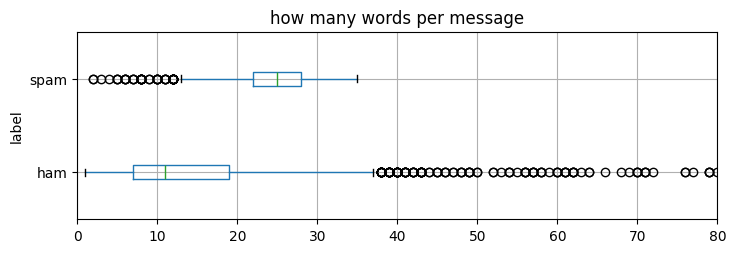

In [3]:
counts = df["label"].value_counts()
print(counts.to_string(), "\n")
print(f"ham = {100 * counts['ham'] / len(df):.1f} % of all messages")

df["words"] = df["text"].str.split().str.len()          # number of words in each message
df.boxplot(column="words", by="label", vert=False, figsize=(8, 2.5))
plt.suptitle(""); plt.title("how many words per message"); plt.xlim(0, 80); plt.show()

👀 **What to notice**

* **About 87 % of the messages are ham.** A lazy "model" that always says "ham" is already **87 % correct**,
  and it catches **zero** spam. So "% correct" (**accuracy**) alone can fool us.
  We will also measure:
  * **spam recall** = of all the real spam, how much did we **catch**? (like a fishing net: how many fish did we get?)
  * **spam precision** = when we say "spam", how often are we **right**? (how much of the net is fish, not old boots?)
* Spam messages are usually **longer**. Most messages have fewer than 40 words, so we will read at most **40 words** per message.

**What this cell does:** shuffles the messages and splits them once: **80 % for training** (the model learns from these)
and **20 % for testing** (kept hidden, like exam questions the student has never seen).

In [4]:
df["y"] = (df["label"] == "spam").astype(int)            # 1 = spam, 0 = ham
shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
cut = int(0.8 * len(shuffled))
train_df, test_df = shuffled[:cut], shuffled[cut:]
print(f"train: {len(train_df):,} messages   test: {len(test_df):,} messages")

train: 4,459 messages   test: 1,115 messages


## Step 2 — Words → numbers

A network can only do maths with **numbers**, not with words. How do we turn text into numbers?
People have tried many ways:

| Way | What it does with "free prize" | Everyday idea | Main problem |
|---|---|---|---|
| **Letter codes** | every letter → its code (f=102, r=114, …) | spelling a word on a keypad | letters carry almost no meaning; "cat" and "car" look alike, "cat" and "kitten" don't |
| **Word IDs** | every word → its page number in a dictionary (free → 51) | a **name tag** with a number | the number itself means nothing: word 51 is not "closer" to word 52 |
| **One-hot** | a long row of 0s with a single 1 at the word's page | a wall of **light switches**, only one is on | a row as long as the dictionary (thousands), and every word is equally far from every other word |
| **Bag of words** | count how often each word appears in the message | a **shopping list**: 2× free, 1× prize | the **order is lost**: "not good, bad" = "good, not bad" |
| **Embeddings** | every word → a short list of numbers the network **learns** | a **place on a map of meaning**: similar words live close together | must be learned from data; needs a lot of text to be good |

We use **word IDs + an embedding**: first every word gets its page number, then the network looks up that page
on its "map of meaning". An RNN then reads the words **in order**, so (unlike the shopping list) the order is kept.

🎨 See it visually: `Training_Visualized/15a_text_to_numbers.html`.

We do it in three small steps: **2a** split into words → **2b** build the dictionary → **2c** make every message the same length.

### 2a — Split a message into words

**What this cell does:** defines `words(text)`: lower-case everything and keep only letters, digits and a few useful
symbols (`£ $ !`, very common in spam). Splitting text into pieces like this is called **tokenizing**.

In [5]:
def words(text):
    return re.findall(r"[a-z0-9£$!]+", text.lower())     # runs of letters/digits/£$! = one word

words("WIN a FREE prize!! Call 0906 now, £1000 waiting")

['win', 'a', 'free', 'prize!!', 'call', '0906', 'now', '£1000', 'waiting']

👀 **What to notice:** "WIN" and "win" become the same word, the comma disappears, and `prize!!`, `£1000` and the phone number survive as words (spammy symbols are kept on purpose).

### 2b — Build the vocabulary (a dictionary with page numbers)

**What this cell does:** counts every word in the **training** messages. Every word that appears at least twice gets its own
**page number**. The list of all known words is called the **vocabulary**. Two special pages:

* `0` = `<pad>`: an **empty seat** (explained in 2c)
* `1` = `<unk>`: "**unk**nown", a word we never saw in training (or saw only once)

The most common word gets page 2, the next one page 3, and so on.

In [6]:
counter = Counter(w for t in train_df["text"] for w in words(t))   # how often each word appears
vocab = {"<pad>": 0, "<unk>": 1}
for w, n in counter.most_common():                                 # most common words first
    if n >= 2:
        vocab[w] = len(vocab)                                      # next free page number
print(f"vocabulary: {len(vocab):,} words\n")

pd.DataFrame({"word": list(vocab)[:12], "page number": range(12)}).set_index("word").T

vocabulary: 3,913 words



word,<pad>,<unk>,i,to,you,a,the,u,and,in,is,me
page number,0,1,2,3,4,5,6,7,8,9,10,11


👀 **What to notice:** about **3,900 words** in our dictionary. The first pages are tiny, everyday words ("i", "to", "you", …)
because they are the most common. Words seen only once (typos, names) all share page `1` = `<unk>`.

### 2c — Same length for every message (padding)

**What this cell does:** defines `to_numbers(text)`, which turns a message into **exactly 40 numbers**:

* too long → keep the first 40 words;
* too short → fill the **empty seats** with `0` (`<pad>`). This is called **padding**.

Like a bus with 40 seats: short groups leave seats empty. We put the empty seats **at the front**,
so the last thing the RNN reads is always the real end of the message.

In [7]:
MAX_LEN = 40

def to_numbers(text):
    ids = [vocab.get(w, 1) for w in words(text)][:MAX_LEN]   # page number, or 1 if unknown; cut at 40
    return [0] * (MAX_LEN - len(ids)) + ids                   # empty seats (0) at the front

print(to_numbers("free prize call now"))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 57, 159, 17, 31]


👀 **What to notice:** 36 zeros (empty seats), then the 4 real words at the end.

### 🔎 One message, step by step

**What this cell does:** follows **one** training message through the whole journey:
text → words → page numbers → padded to 40 → **embedding** (every word becomes 32 numbers, its "address on the map of meaning").

In [8]:
example = train_df["text"].iloc[3]
toks = words(example)
print("1) text   :", example)
print("2) words  :", toks, "\n")

print("3) word → page number")
print(pd.DataFrame({"word": toks, "number": [vocab.get(w, 1) for w in toks]}).T.to_string(header=False), "\n")

padded = to_numbers(example)
print(f"4) padded to {MAX_LEN}:", padded)

demo_emb = nn.Embedding(len(vocab), 32)                      # a (still random) map: page number → 32 numbers
vectors = demo_emb(torch.tensor([padded]))
print("\n5) after the embedding:", tuple(vectors.shape), "= (1 message, 40 words, 32 numbers per word)")
print("   the 32 numbers for 'sorry':", vectors[0, -len(toks)].detach().numpy().round(2)[:8], "...")

1) text   : Sorry i've not gone to that place. I.ll do so tomorrow. Really sorry.
2) words  : ['sorry', 'i', 've', 'not', 'gone', 'to', 'that', 'place', 'i', 'll', 'do', 'so', 'tomorrow', 'really', 'sorry'] 

3) word → page number
word    sorry  i   ve  not  gone  to  that  place  i  ll  do  so  tomorrow  really  sorry
number     90  2  139   29   902   3    20    208  2  56  34  26       157     158     90 

4) padded to 40: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 90, 2, 139, 29, 902, 3, 20, 208, 2, 56, 34, 26, 157, 158, 90]

5) after the embedding: (1, 40, 32) = (1 message, 40 words, 32 numbers per word)
   the 32 numbers for 'sorry': [ 0.86  1.27 -1.14  0.26 -1.25  0.67 -0.88  1.4 ] ...


👀 **What to notice**

* "sorry" gets the same number (`90`) both times it appears, and so does "i" (`2`). Every word always gets **the same page**.
* `I.ll` became two words, `i` and `ll`. Our simple splitter is not perfect, and that is fine.
* At the end every word is a list of **32 numbers**. Right now they are random. During training the network moves the words
  around on its map, so that words used in similar ways (e.g. "free", "win", "prize") end up **close together**.

**What this cell does:** turns **all** messages into numbers at once and stores them in **tensors**
(a tensor = a grid of numbers, PyTorch's version of a table).

In [9]:
def tensors(frame):
    x = torch.tensor([to_numbers(t) for t in frame["text"]])   # (messages, 40) page numbers
    y = torch.tensor(frame["y"].values)                         # the right answers: 0 = ham, 1 = spam
    return x, y

x_train, y_train = tensors(train_df)
x_test, y_test = tensors(test_df)
print("x_train:", tuple(x_train.shape), "= (messages, words)")

x_train: (4459, 40) = (messages, words)


👀 **What to notice:** our whole training set is now one table: 4,459 rows (messages) × 40 columns (seats).

## Step 3 — Watch an RNN read one message

Our model has three parts:

```
page numbers ──► Embedding ──► RNN ──► Linear ──► [ham score, spam score]
   (40)          each word →   reads the words      looks only at the LAST
                 32 numbers    one by one and       whiteboard: "what did the
                               updates a 64-number  whole message say?"
                               whiteboard
```

* **RNN** = **r**ecurrent **n**eural **n**etwork. "Recurrent" = it does the same thing again and again, once per word.
* The **whiteboard** is officially called the **hidden state**: 64 numbers that summarize "what I have read so far".
* At every word: *new whiteboard = mix(this word, old whiteboard)*. The same reader (the same weights) is used for every word.

**What this cell does:** builds an **untrained** embedding + RNN and sends our example message through it, printing the shapes.

In [10]:
emb = nn.Embedding(len(vocab), 32)                           # page number → 32 numbers
rnn = nn.RNN(input_size=32, hidden_size=64, batch_first=True)  # whiteboard of 64 numbers

one = x_train[3:4]                                   # 1 message, 40 page numbers
vectors = emb(one)                                   # (1, 40, 32)
all_boards, last_board = rnn(vectors)                # whiteboard after every word, and the final one
print("input words        :", tuple(one.shape))
print("after Embedding    :", tuple(vectors.shape), "  (1 message, 40 words, 32 numbers per word)")
print("whiteboard per word:", tuple(all_boards.shape), "  (a 64-number whiteboard after every word)")
print("last whiteboard    :", tuple(last_board.shape), "  (this goes to the Linear layer)")

input words        : (1, 40)
after Embedding    : (1, 40, 32)   (1 message, 40 words, 32 numbers per word)
whiteboard per word: (1, 40, 64)   (a 64-number whiteboard after every word)
last whiteboard    : (1, 1, 64)   (this goes to the Linear layer)


👀 **What to notice:** 40 words in → 40 whiteboards out (one after each word). Only the **last** one is used to decide spam or ham.

**What this cell does:** draws the 64 whiteboard numbers after every word as colours (red = high, blue = low).

### Why an LSTM and not a plain RNN?

A plain RNN **rewrites its whole whiteboard** at every word. After many words, notes from the start get smudged
and disappear: it **forgets the beginning** of long messages. (The technical name for this is the **vanishing gradient** problem:
during learning, the signal from early words becomes too weak to matter.)

An **LSTM** (**L**ong **S**hort-**T**erm **M**emory) is an RNN with a smarter whiteboard. It gets a second, protected
notebook (the **cell state**) and three tools, called **gates**. A gate is a small dial between 0 (closed) and 1 (open) that the network learns:

| Gate | Tool | Question it answers |
|---|---|---|
| 🚪 forget gate | **eraser** | what old notes should I wipe out now? |
| 📥 input gate | **pen** | what from this new word is worth writing down? |
| 📤 output gate | **cover** | which part of my notes should I show to the next layer right now? |

Because notes are only changed through these tools (mostly by **adding**, not rewriting everything), important notes can survive
many more words. In PyTorch the change is one word: `nn.RNN` → `nn.LSTM`.

## Step 4 — Train an LSTM spam detector

**What this cell does:** puts the three parts together into one model. `kind` chooses the reader: `"lstm"`, `"rnn"` or `"gru"`
(a GRU is a lighter LSTM with only two gates).

In [12]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, kind="lstm", emb_dim=32, hidden=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)     # padding_idx=0: empty seats stay all-zero
        layer = {"lstm": nn.LSTM, "rnn": nn.RNN, "gru": nn.GRU}[kind]
        self.seq = layer(emb_dim, hidden, batch_first=True)             # the reader with its 64-number whiteboard
        self.out = nn.Linear(hidden, 2)                                 # whiteboard → 2 scores (ham, spam)

    def forward(self, x):                      # x: (batch, 40) page numbers
        all_boards, _ = self.seq(self.emb(x))
        return self.out(all_boards[:, -1])     # only the whiteboard after the LAST word

**What this cell does:** defines `score(model, x, y)`, our "exam marker". It counts:

* **TP** (true positive) = spam we called spam ✅
* **FP** (false positive) = ham we wrongly called spam (a real message lost in the spam folder) ❌
* **FN** (false negative) = spam we let through ❌

and turns them into accuracy, spam recall and spam precision (in %).

In [13]:
@torch.inference_mode()                        # just answering, no learning → faster
def score(model, x, y):
    model.eval()
    pred = model(x).argmax(1)                  # the higher of the 2 scores wins: 0 = ham, 1 = spam
    tp = ((pred == 1) & (y == 1)).sum().item()
    fp = ((pred == 1) & (y == 0)).sum().item()
    fn = ((pred == 0) & (y == 1)).sum().item()
    return {"accuracy_%": round(100 * (pred == y).float().mean().item(), 1),
            "spam_recall_%": round(100 * tp / max(tp + fn, 1), 1),       # of all spam: how much caught?
            "spam_precision_%": round(100 * tp / max(tp + fp, 1), 1)}, pred   # of all "spam" calls: how many right?

**What this cell does:** defines `train(kind)`: the usual training loop from Day 1. In every **epoch** (one full pass over all
4,459 training messages) the model reads 64 messages at a time, sees its mistakes and adjusts itself a little.
After every epoch we mark it on the test messages.

In [14]:
def train(kind, epochs=6):
    torch.manual_seed(0)                       # same start for every model → fair comparison
    model = TextClassifier(len(vocab), kind)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    loss_fn = nn.CrossEntropyLoss()            # "how wrong was the answer?"
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
    history, start = [], time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:                  # 64 messages at a time
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()   # learn from the mistakes
        scores, _ = score(model, x_test, y_test)
        history.append(scores)
        print(f"{kind.upper():4s} epoch {epoch}: last batch loss {loss.item():.3f} | test " +
              " | ".join(f"{k} {v}" for k, v in scores.items()))
    print(f"⏱️ {time.perf_counter() - start:.0f} s\n")
    return model, history

**What this cell does:** trains the LSTM for 6 epochs (a few seconds).

In [15]:
lstm, lstm_history = train("lstm")

LSTM epoch 1: last batch loss 0.086 | test accuracy_% 95.7 | spam_recall_% 86.5 | spam_precision_% 83.2
LSTM epoch 2: last batch loss 0.020 | test accuracy_% 97.3 | spam_recall_% 86.5 | spam_precision_% 93.7
LSTM epoch 3: last batch loss 0.021 | test accuracy_% 97.8 | spam_recall_% 87.7 | spam_precision_% 95.8
LSTM epoch 4: last batch loss 0.117 | test accuracy_% 97.8 | spam_recall_% 88.4 | spam_precision_% 95.8
LSTM epoch 5: last batch loss 0.002 | test accuracy_% 98.2 | spam_recall_% 90.3 | spam_precision_% 96.6
LSTM epoch 6: last batch loss 0.002 | test accuracy_% 98.2 | spam_recall_% 91.6 | spam_precision_% 95.3
⏱️ 3 s



👀 **What to notice**

* Already after epoch 1 the LSTM is **95.7 % correct** and catches **86.5 %** of the spam.
* By epoch 6: about **98 % correct**, it catches about **92 %** of the spam (recall), and when it says "spam" it is right about **95 %** of the time (precision).
* The **loss** (how wrong the answers are) jumps up and down a little from batch to batch. That is normal; the trend is what counts.

**What this cell does:** draws a **confusion matrix**: a 2×2 table of *true answer* vs *model's answer* for the 1,115 test messages.

In [16]:
scores, pred = score(lstm, x_test, y_test)
names = {0: "ham", 1: "spam"}
cm = pd.crosstab(pd.Series(y_test.numpy(), name="true").map(names),
                 pd.Series(pred.numpy(), name="predicted").map(names))
print(scores)
cm

{'accuracy_%': 98.2, 'spam_recall_%': 91.6, 'spam_precision_%': 95.3}


predicted,ham,spam
true,,
ham,953,7
spam,13,142


👀 **What to notice:** the interesting numbers are the **mistakes** (outside the diagonal):

* *true spam → predicted ham* (**13**): spam that got through to the inbox. Annoying.
* *true ham → predicted spam* (**7**): a real message hidden in the spam folder. Worse: you might miss "the meeting moved to 3 pm"!

The LSTM learned all of this from the raw words, with no hand-written rules like "if the message contains FREE".

## Step 5 — Is the LSTM worth it? Compare

Three contenders on the same test messages:

1. 😴 **always "ham"**: the lazy baseline (never learns anything)
2. **plain RNN**: same model, same size, same training, but `nn.RNN` instead of `nn.LSTM` (whiteboard without eraser, pen and cover)
3. **LSTM**: from Step 4

**What this cell does:** trains the plain RNN exactly like the LSTM.

In [17]:
rnn_model, rnn_history = train("rnn")

RNN  epoch 1: last batch loss 0.383 | test accuracy_% 85.4 | spam_recall_% 41.9 | spam_precision_% 47.1
RNN  epoch 2: last batch loss 0.153 | test accuracy_% 94.3 | spam_recall_% 62.6 | spam_precision_% 95.1
RNN  epoch 3: last batch loss 0.086 | test accuracy_% 95.6 | spam_recall_% 72.9 | spam_precision_% 94.2
RNN  epoch 4: last batch loss 0.056 | test accuracy_% 96.1 | spam_recall_% 85.8 | spam_precision_% 86.4
RNN  epoch 5: last batch loss 0.114 | test accuracy_% 97.3 | spam_recall_% 84.5 | spam_precision_% 95.6
RNN  epoch 6: last batch loss 0.011 | test accuracy_% 97.7 | spam_recall_% 85.8 | spam_precision_% 97.1
⏱️ 3 s



👀 **What to notice:** after epoch 1 the plain RNN catches only about **4 in 10** spam messages (the LSTM already caught almost 9 in 10). It learns more slowly.

**What this cell does:** puts the three contenders in one table.

In [18]:
lazy = {"accuracy_%": round(100 * (y_test == 0).float().mean().item(), 1),   # always "ham": right for every ham message
        "spam_recall_%": 0.0, "spam_precision_%": 0.0}                       # ...and catches no spam at all
table = pd.DataFrame([{"model": "always 'ham'", **lazy},
                      {"model": "plain RNN", **score(rnn_model, x_test, y_test)[0]},
                      {"model": "LSTM", **score(lstm, x_test, y_test)[0]}]).set_index("model")
table

,accuracy_%,spam_recall_%,spam_precision_%
model,,,
always 'ham',86.1,0.0,0.0
plain RNN,97.7,85.8,97.1
LSTM,98.2,91.6,95.3


**What this cell does:** draws the table (left) and how much spam each model caught after every epoch (right).

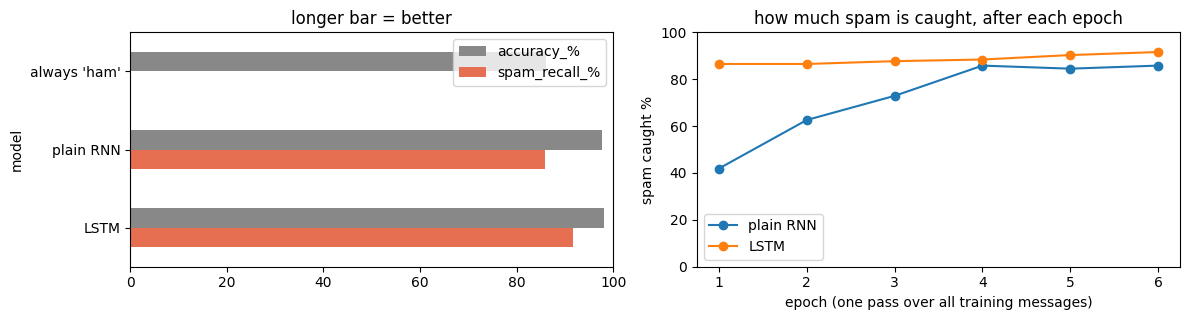

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.3))
table[["accuracy_%", "spam_recall_%"]].plot.barh(ax=axes[0], color=["#888", "#e76f51"])
axes[0].set_xlim(0, 100); axes[0].set_title("longer bar = better"); axes[0].invert_yaxis()
for name, h in [("plain RNN", rnn_history), ("LSTM", lstm_history)]:
    axes[1].plot(range(1, len(h) + 1), [s["spam_recall_%"] for s in h], marker="o", label=name)
axes[1].set_xlabel("epoch (one pass over all training messages)"); axes[1].set_ylabel("spam caught %"); axes[1].set_ylim(0, 100)
axes[1].set_title("how much spam is caught, after each epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

👀 **What to notice**

* The lazy baseline is **86 % correct** on these test messages and catches **no spam at all**. That's why we never trust accuracy alone.
* The **plain RNN** ends at **97.7 % correct / 85.8 % of spam caught**; the **LSTM** at **98.2 % / 91.6 %**.
  The LSTM catches about **9 more spam messages** out of the 155 in the test set.
  (The plain RNN even has a slightly higher precision here: it says "spam" a bit less often, so it is wrong less often when it does.)
  Same data, same size, same training: the only difference is the LSTM's **gates** (eraser, pen, cover).
* SMS messages are short, so the gap is modest here. On long texts (reviews, emails) a plain RNN forgets the beginning, and the gap gets much bigger.

## Step 6 — Try your own messages

**What this cell does:** defines `spam_probability(text)`, which turns any text into numbers (exactly like the training messages)
and returns the LSTM's **probability of spam**: 0 = surely ham, 1 = surely spam. Then it tests 5 messages.
Change the texts and run it again!

In [20]:
@torch.inference_mode()
def spam_probability(text, model=lstm):
    model.eval()
    scores = model(torch.tensor([to_numbers(text)]))         # same preparation as training
    return torch.softmax(scores, 1)[0, 1].item()             # softmax: 2 scores → 2 probabilities; [1] = spam

for text in ["Congratulations! You have won a FREE prize. Call 09061701461 now to claim £1000",
             "Hey, are we still meeting for lunch tomorrow?",
             "URGENT: your mobile number has been selected for a cash reward, text WIN to 80086",
             "Can you send me the notes from today's lecture please",
             "are you free tonight? call me"]:
    p = spam_probability(text)
    print(f"{'🚫 spam' if p > 0.5 else '✅ ham '}  {p:5.2f}  {text}")

🚫 spam   1.00  Congratulations! You have won a FREE prize. Call 09061701461 now to claim £1000
✅ ham    0.00  Hey, are we still meeting for lunch tomorrow?
🚫 spam   1.00  URGENT: your mobile number has been selected for a cash reward, text WIN to 80086
✅ ham    0.00  Can you send me the notes from today's lecture please
✅ ham    0.00  are you free tonight? call me


👀 **What to notice:** the last message contains "free" and "call", two very spammy words, but the model still says ham.
It does not just look for single words: it reads the whole message, and short, casual messages "feel" like ham.
Can you write a message that fools it? It only knows the patterns it saw in 4,459 training messages.

## 🎓 What to remember

1. **Text is a sequence.** An **RNN** reads it one word at a time and keeps a small **whiteboard** (the hidden state) of what it has read so far.
2. Recipe: **words → page numbers (vocabulary) → padding to the same length → Embedding (a place on the map of meaning) → RNN/LSTM → decide from the last whiteboard**.
3. A plain RNN **forgets** early words. An **LSTM** has an **eraser, a pen and a cover** (forget, input, output gates), so it remembers longer. In code: `nn.RNN` → `nn.LSTM`.
4. When one class is rare (13 % spam), **accuracy lies**: "always ham" is 86 % correct. Check **recall** (how much spam we catch) and **precision** (how often "spam" is right), and compare with a lazy baseline.
5. The same recipe sorts **any** text: reviews (positive/negative), news topics, chatbot requests ("book a table", "cancel order").
   Modern chatbots use **Transformers** instead of LSTMs, but the idea "text → numbers → model → answer" is the same.

## ✍️ Try it yourself

**Exercise 1 — the dictionary.** What numbers does `to_numbers("hello zzqqxx my friend")` give? Why does `zzqqxx` get the number it gets?

In [21]:
# your code here

<details><summary>Answer</summary>

```python
print(to_numbers("hello zzqqxx my friend"))
```

You get **36 zeros** (empty seats) followed by **265, 1, 12, 246**. `zzqqxx` gets **1** = `<unk>`: it is not in our dictionary because it never
appeared in the training messages. Every unknown word gets the same page 1, so the model cannot tell different unknown words apart.

</details>

**Exercise 2 — a lighter LSTM.** Train a **GRU** (an LSTM with only 2 gates) with one line, and add it to the comparison. Is it closer to the RNN or to the LSTM?

In [22]:
# your code here

<details><summary>Answer</summary>

```python
gru_model, gru_history = train("gru")
print(score(gru_model, x_test, y_test)[0])
```

The GRU ends at about **98.7 % correct, 91.6 % of spam caught, 98.6 % precision**: as good as the LSTM (even a bit more precise),
and clearly better than the plain RNN (85.8 % caught). Two gates are enough for short SMS messages, and a GRU is smaller and a little faster than an LSTM.

</details>

**Exercise 3 — a shorter bus.** What if we only read the first **10 words** of every message? Set `MAX_LEN = 10`, rebuild the tensors and train the LSTM again.
What happens to spam recall? (Afterwards set `MAX_LEN = 40` and re-run from Step 2c, so the rest of the notebook is correct again.)

In [23]:
# your code here

<details><summary>Answer</summary>

```python
MAX_LEN = 10
x_train, y_train = tensors(train_df)
x_test, y_test = tensors(test_df)
short_lstm, _ = train("lstm")
```

Spam recall drops from **91.6 %** to about **81 %** (accuracy from 98.2 % to about 96.5 %).
With only 10 seats on the bus, the model never sees the end of longer messages, and spam is usually long:
the "call 0906… to claim £1000" part often comes after word 10. Reading more of the message helps.

Don't forget: set `MAX_LEN = 40` again and re-run from Step 2c.

</details>

**Want more?** The full notebook `07_rnn_lstm_text.ipynb` has the same steps in compact form, and `Training_Visualized/15_rnn_lstm.html` animates the whiteboard and the gates.